In [3]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

In [ ]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol without an attacker.



In [6]:
import numpy as np
import matplotlib.pyplot as plt

simulator = BasicSimulator()
print('Ready!!')

Ready!!


In [7]:
def quantum_random_bit():
  qc = QuantumCircuit(1, 1)
  qc.h(0) # Hadamard gate
  qc.measure(0, 0)
  job = simulator.run(transpile(qc, simulator), shots=1, memory=True)
  return int(job.result().get_memory()[0])

def quantum_random_bits(n: int) -> list:
    return [quantum_random_bit() for _ in range(n)]

# Test
test_bits = quantum_random_bits(20)
print("Quantum random bits: ", test_bits)
print("Proportion of 1s: ", sum(test_bits)/len(test_bits))

Quantum random bits:  [1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1]
Proportion of 1s:  0.4


In [8]:
# Alice
def alice_encode(bit: int, basis: int) -> QuantumCircuit:
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)       # Flip |0> -> |1>
    if basis == 1:
        qc.h(0)
    return qc

N = 100 # No of qubits Alices will send

alice_bits  = quantum_random_bits(N)   # Alice's secret bits
alice_bases = quantum_random_bits(N)   # Alice's encoding bases
alice_qubits = [alice_encode(alice_bits[i], alice_bases[i]) for i in range(N)]

print("Alice first 20 bits: ", alice_bits[:20])
print("Alice first 20 bases: ", alice_bases[:20])

Alice first 20 bits:  [0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0]
Alice first 20 bases:  [0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1]


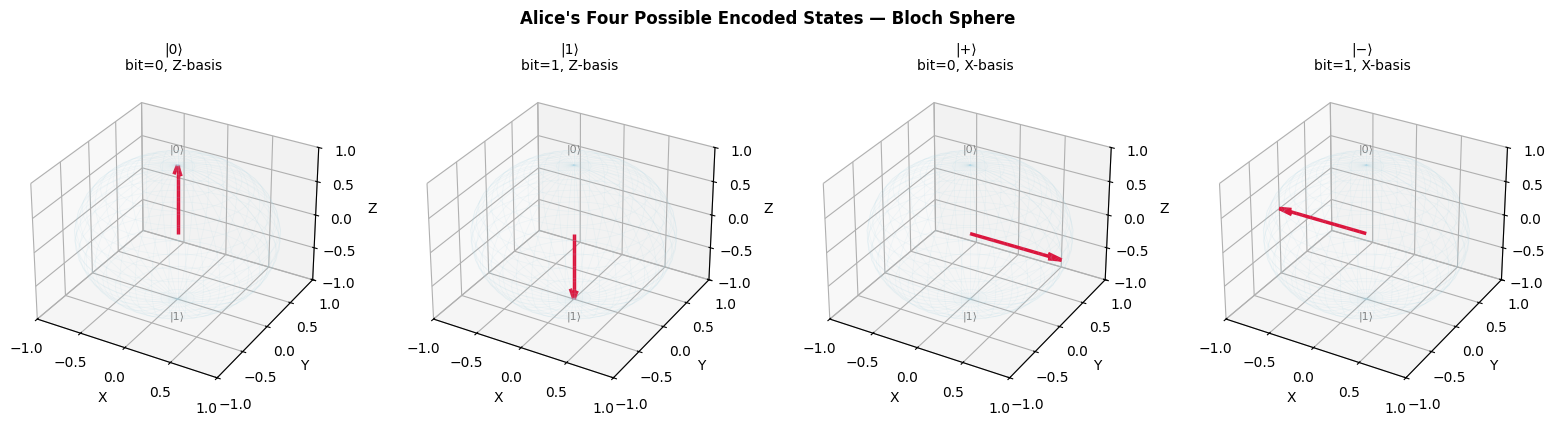

In [9]:
# Alice visualisation
fig, axes = plt.subplots(1, 4, figsize=(16, 4),
                         subplot_kw={'projection': '3d'})

states = [
    (0, 0, '|0⟩\nbit=0, Z-basis'),
    (1, 0, '|1⟩\nbit=1, Z-basis'),
    (0, 1, '|+⟩\nbit=0, X-basis'),
    (1, 1, '|−⟩\nbit=1, X-basis'),
]

for ax, (bit, basis, label) in zip(axes, states):
    sv = Statevector(alice_encode(bit, basis))

    # Draw wireframe sphere
    u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
    ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                      color='lightblue', alpha=0.15, linewidth=0.5)

    # Bloch vector from statevector
    dm = sv.data
    bx = 2 * np.real(dm[0] * np.conj(dm[1]))
    by = 2 * np.imag(dm[1] * np.conj(dm[0]))
    bz = abs(dm[0])**2 - abs(dm[1])**2

    ax.quiver(0, 0, 0, bx, by, bz, color='crimson',
              linewidth=2.5, arrow_length_ratio=0.15)

    ax.set_xlim([-1,1]); ax.set_ylim([-1,1]); ax.set_zlim([-1,1])
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(label, fontsize=10)
    ax.text(0, 0,  1.2, '|0⟩', ha='center', fontsize=8, color='gray')
    ax.text(0, 0, -1.3, '|1⟩', ha='center', fontsize=8, color='gray')

plt.suptitle("Alice's Four Possible Encoded States — Bloch Sphere",
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# Bob
def bob_measure(qubit_circuit: QuantumCircuit, basis: int):
    qc = qubit_circuit.copy()
    if basis == 1:
        qc.h(0)       # Rotate back from X basis before measuring
    qc.measure(0, 0)
    job = simulator.run(transpile(qc, simulator), shots=1, memory=True)
    return int(job.result().get_memory()[0])

bob_bases = quantum_random_bits(N)
bob_results = [bob_measure(alice_qubits[i], bob_bases[i]) for i in range(N)]

print("Bob first 20 bases: ", bob_bases[:20])
print("Bob first 20 results: ", bob_results[:20])

Bob first 20 bases:  [1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0]
Bob first 20 results:  [1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0]


In [12]:
def sift_key(alice_bits, alice_bases, bob_results, bob_bases):
    sifted_alice, sifted_bob = [], []
    for i in range(len(alice_bits)):
        if alice_bases[i] == bob_bases[i]:
            sifted_alice.append(alice_bits[i])
            sifted_bob.append(bob_results[i])
    return sifted_alice, sifted_bob

sifted_alice, sifted_bob = sift_key(
    alice_bits, alice_bases, bob_results, bob_bases
)

print("Number of qubits sent: ", N)
print("Sifted key length: ", len(sifted_alice))
print("Alice sifted key (first 20): ", sifted_alice)
print("Bob sifted key (first 20): ", sifted_bob)
print(f"Are the keys identical? {sifted_alice == sifted_bob}!")

Number of qubits sent:  100
Sifted key length:  49
Alice sifted key (first 20):  [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0]
Bob sifted key (first 20):  [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0]
Are the keys identical? True!


In [16]:
DETECTION_THRESHOLD = 0.10   # abort if QBER > 10%
SAMPLE_FRACTION     = 0.50   # use 50% of sifted key for checking

n_check       = int(len(sifted_alice) * SAMPLE_FRACTION)
check_alice   = sifted_alice[:n_check]
check_bob     = sifted_bob[:n_check]
final_alice   = sifted_alice[n_check:]
final_bob     = sifted_bob[n_check:]

mismatches = sum(a != b for a, b in zip(check_alice, check_bob))
qber = mismatches / n_check if n_check > 0 else 0.0

print("Bits used for QBER check: ", n_check)
print("Mismatches found: ", mismatches)
print("QBER: ", qber)
print("Detection threshold: " + f"{DETECTION_THRESHOLD*100}" + "%")
print("Final key length (bits): ", len(final_alice))

if qber > DETECTION_THRESHOLD:
  print("ATTACK DETECTED! KEY EXCHANGE ABORT!")
else:
  print("No attack detected, secure key established!")
  print("Final Alice Key: ", final_alice)
  print("Final Bob Key: ", final_bob)
  print(f"Do the keys match? {final_alice == final_bob}!")

Bits used for QBER check:  24
Mismatches found:  0
QBER:  0.0
Detection threshold: 10.0%
Final key length (bits):  25
No attack detected, secure key established!
Final Alice Key:  [1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0]
Final Bob Key:  [1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0]
Do the keys match? True!


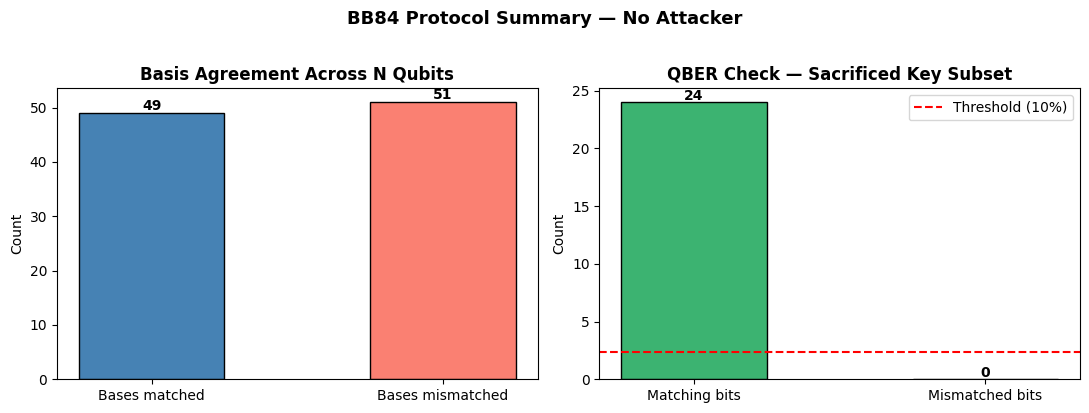

In [17]:
# Visualisation of what broke down in all qubits!
basis_match    = sum(a == b for a, b in zip(alice_bases, bob_bases))
basis_mismatch = N - basis_match

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: basis agreement
axes[0].bar(['Bases matched', 'Bases mismatched'],
            [basis_match, basis_mismatch],
            color=['steelblue', 'salmon'], edgecolor='black', width=0.5)
axes[0].set_title('Basis Agreement Across N Qubits', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([basis_match, basis_mismatch]):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Right: QBER check result
axes[1].bar(['Matching bits', 'Mismatched bits'],
            [n_check - mismatches, mismatches],
            color=['mediumseagreen', 'tomato'], edgecolor='black', width=0.5)
axes[1].axhline(n_check * DETECTION_THRESHOLD, color='red',
                linestyle='--', linewidth=1.5,
                label=f'Threshold ({DETECTION_THRESHOLD*100:.0f}%)')
axes[1].set_title('QBER Check — Sacrificed Key Subset', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].legend()
for i, v in enumerate([n_check - mismatches, mismatches]):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.suptitle('BB84 Protocol Summary — No Attacker', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()